In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
df = pd.read_csv('Bangalore.csv')
df.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,30000000,3340,JP Nagar Phase 1,4,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0


In [23]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Stadium'],
      dtype='object')


In [24]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6207 entries, 0 to 6206
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                6207 non-null   int64 
 1   Area                 6207 non-null   int64 
 2   Location             6207 non-null   object
 3   No. of Bedrooms      6207 non-null   int64 
 4   Resale               6207 non-null   int64 
 5   MaintenanceStaff     6207 non-null   int64 
 6   Gymnasium            6207 non-null   int64 
 7   SwimmingPool         6207 non-null   int64 
 8   LandscapedGardens    6207 non-null   int64 
 9   JoggingTrack         6207 non-null   int64 
 10  RainWaterHarvesting  6207 non-null   int64 
 11  IndoorGames          6207 non-null   int64 
 12  ShoppingMall         6207 non-null   int64 
 13  Intercom             6207 non-null   int64 
 14  SportsFacility       6207 non-null   int64 
 15  ATM                  6207 non-null   int64 
 16  ClubHo

Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Stadium                0


In [25]:
df = df.dropna()   # simple approach

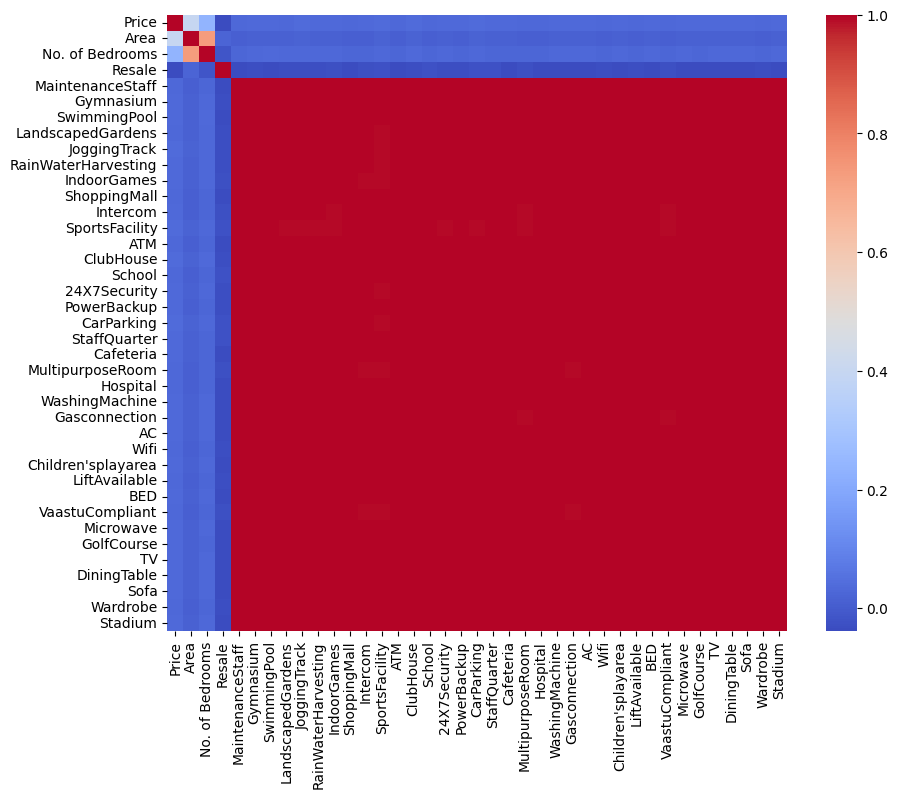

In [26]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

In [27]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Stadium'],
      dtype='object')


In [28]:
print(df.columns)

Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Stadium'],
      dtype='object')


In [29]:
X = df[['Area']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_slr = LinearRegression()
model_slr.fit(X_train, y_train)

y_pred_slr = model_slr.predict(X_test)

print("SLR R2:", r2_score(y_test, y_pred_slr))
print("SLR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_slr)))

SLR R2: 0.1283845921331218
SLR RMSE: 15295065.475018073


In [30]:
X = df.drop('Price', axis=1)
y = df['Price']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_mlr = LinearRegression()
model_mlr.fit(X_train, y_train)

y_pred_mlr = model_mlr.predict(X_test)

print("MLR R2:", r2_score(y_test, y_pred_mlr))
print("MLR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlr)))

MLR R2: 0.18102415588439713
MLR RMSE: 14826015.069158258


In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model_pca = LinearRegression()
model_pca.fit(X_train, y_train)

y_pred_pca = model_pca.predict(X_test)

print("PCA R2:", r2_score(y_test, y_pred_pca))
print("PCA RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_pca)))

PCA R2: 0.12356285978392345
PCA RMSE: 15337312.892240793


In [32]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Lasso R2: 0.12356286006479056
Ridge R2: 0.12356032780846815


In [33]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

print("SVR R2:", r2_score(y_test, y_pred_svr))

SVR R2: -0.03240375554400243


In [34]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT R2:", r2_score(y_test, y_pred_dt))

DT R2: -0.08915659186823355


In [35]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.16581034166345043


In [36]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [37]:
from scipy.stats import uniform

param_dist = {
    'C': uniform(1, 10),
    'gamma': ['scale', 'auto']
}

random_search = RandomizedSearchCV(SVR(), param_dist, n_iter=10, cv=3)
random_search.fit(X_train, y_train)

best_svr = random_search.best_estimator_

In [38]:
results = pd.DataFrame({
    'Model': ['SLR', 'MLR', 'PCA', 'Lasso', 'Ridge', 'SVR', 'DT', 'RF'],
    'R2 Score': [
        r2_score(y_test, y_pred_slr),
        r2_score(y_test, y_pred_mlr),
        r2_score(y_test, y_pred_pca),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results.sort_values(by='R2 Score', ascending=False))

   Model  R2 Score
1    MLR  0.181024
7     RF  0.165810
0    SLR  0.128385
3  Lasso  0.123563
2    PCA  0.123563
4  Ridge  0.123560
5    SVR -0.032404
6     DT -0.089157


----------------------------------------------------------------------------------------

Task 2 : Predicting Customer Churn

----------------------------------------------------------------------------------------

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_squared_error

In [40]:
df = pd.read_csv("BankChurners/BankChurners.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0                  777          11914.0   
1       

In [41]:
df = df.select_dtypes(include=np.number)
df = df.dropna()

In [42]:
df["SalePrice"] = df.iloc[:,0]*10 + df.iloc[:,1]*5

In [43]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
X_area_train = X_train.iloc[:, [0]]
X_area_test = X_test.iloc[:, [0]]

model1 = LinearRegression()
model1.fit(X_area_train, y_train)

pred1 = model1.predict(X_area_test)

print("Simple LR R2:", r2_score(y_test, pred1))

Simple LR R2: 0.9999999999999882


In [45]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("Multiple LR R2:", r2_score(y_test, pred2))

Multiple LR R2: 1.0


In [46]:
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_pca, y_train)

pred3 = model3.predict(X_test_pca)

print("PCA R2:", r2_score(y_test, pred3))

PCA R2: 0.9999999999999883


In [47]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Ridge:", r2_score(y_test, ridge.predict(X_test)))
print("Lasso:", r2_score(y_test, lasso.predict(X_test)))

Ridge: 1.0
Lasso: 1.0


c:\Python313\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.054179382542567e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [48]:
svr = SVR()
svr.fit(X_train, y_train)

print("SVR:", r2_score(y_test, svr.predict(X_test)))

SVR: -0.3396149994496984


In [49]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

print("Decision Tree:", r2_score(y_test, dt.predict(X_test)))

Decision Tree: 0.9999963272951918


In [50]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("Random Forest:", r2_score(y_test, rf.predict(X_test)))

Random Forest: 0.9999989844727485


In [51]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=3)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'n_estimators': 50}


In [52]:
models = {
    "Linear": model2,
    "Ridge": ridge,
    "Lasso": lasso,
    "Tree": dt,
    "Forest": rf
}

for name, m in models.items():
    pred = m.predict(X_test)
    print(name, "R2:", r2_score(y_test, pred))

Linear R2: 1.0
Ridge R2: 1.0
Lasso R2: 1.0
Tree R2: 0.9999963272951918
Forest R2: 0.9999989844727485
